In [ ]:
!pip install librosa soundfile seaborn

In [ ]:
import zipfile
import os

zip_path = "/content/Audio_Speech_Actors_01-24 (1).zip"   # change if filename differs
extract_path = "/content/ravdess"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

Extracted to: /content/ravdess


In [ ]:
DATASET_PATH = "/content/ravdess"

In [ ]:
import os
print(os.listdir(DATASET_PATH)[:10])

['Actor_03', 'Actor_10', 'Actor_17', 'Actor_20', 'Actor_16', 'Actor_19', 'Actor_05', 'Actor_11', 'Actor_06', 'Actor_22']


In [ ]:
"""
====================================================================
 Speech Emotion Recognition — Deliverable 1
 Exploratory Data Analysis: RAVDESS Dataset
====================================================================
 Author  : [Your Name]
 Course  : Foundations of Machine Learning
 Dataset : RAVDESS (Livingstone & Russo, 2018)
           https://doi.org/10.5281/zenodo.1188976

 Structure
 ---------
 0. Imports & Configuration
 1. Dataset Loading & Metadata Parsing
 2. Class Distribution Analysis
 3. Gender Distribution
 4. Audio Duration Analysis
 5. Missing / Corrupted File Detection
 6. Waveform Visualisation
 7. Spectrogram Visualisation
 8. Mel Spectrogram Visualisation
 9. MFCC Visualisation
10. Summary Statistics Table

 Usage
 -----
 Place this script in the root of your project folder.
 Set DATASET_PATH to the directory containing the 24 actor
 sub-folders (e.g. Actor_01/, Actor_02/, ...).

 pip install librosa matplotlib seaborn pandas numpy soundfile
====================================================================
"""

# ──────────────────────────────────────────────────────────────────
# 0. IMPORTS & CONFIGURATION
# ──────────────────────────────────────────────────────────────────
import os
import glob
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ── Dataset path ───────────────────────────────────────────────────
# TODO: Update this path to where your RAVDESS audio files are stored.
# Expected structure: DATASET_PATH/Actor_01/03-01-01-01-01-01-01.wav
DATASET_PATH = "/content/ravdess"          # ← change me

# ── Plot aesthetics ────────────────────────────────────────────────
FIGURE_DPI   = 150
SAVE_FIGURES = True                 # set False to display interactively
OUTPUT_DIR   = "./eda_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi":        FIGURE_DPI,
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   10,
})

EMOTION_MAP = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fearful",
    "07": "Disgust",
    "08": "Surprised",
}

EMOTION_PALETTE = {
    "Neutral":   "#8B8FA8",
    "Calm":      "#6EC6CA",
    "Happy":     "#F9C74F",
    "Sad":       "#577590",
    "Angry":     "#E63946",
    "Fearful":   "#9B5DE5",
    "Disgust":   "#43AA8B",
    "Surprised": "#F77F00",
}

INTENSITY_MAP  = {"01": "Normal", "02": "Strong"}
GENDER_MAP     = lambda actor_id: "Female" if int(actor_id) % 2 == 0 else "Male"


def save_or_show(fig: plt.Figure, name: str) -> None:
    """Save the figure to OUTPUT_DIR or display it interactively."""
    if SAVE_FIGURES:
        path = os.path.join(OUTPUT_DIR, f"{name}.png")
        fig.savefig(path, bbox_inches="tight", facecolor="white")
        print(f"  ✓ Saved: {path}")
        plt.close(fig)
    else:
        plt.show()


# ──────────────────────────────────────────────────────────────────
# 1. DATASET LOADING & METADATA PARSING
# ──────────────────────────────────────────────────────────────────
def parse_filename(filepath: str) -> dict:
    """
    Parse a RAVDESS filename into its 7 metadata fields.

    Filename format: MM-VC-EM-EI-ST-RE-AC.wav
    MM = Modality, VC = Vocal channel, EM = Emotion,
    EI = Emotional intensity, ST = Statement,
    RE = Repetition, AC = Actor
    """
    stem = Path(filepath).stem          # e.g. "03-01-06-01-02-01-12"
    parts = stem.split("-")
    if len(parts) != 7:
        return {"filepath": filepath, "parse_error": True}

    actor_id = parts[6]
    return {
        "filepath":  filepath,
        "modality":  parts[0],
        "vocal_ch":  parts[1],
        "emotion_id": parts[2],
        "emotion":   EMOTION_MAP.get(parts[2], "Unknown"),
        "intensity_id": parts[3],
        "intensity": INTENSITY_MAP.get(parts[3], "Unknown"),
        "statement": parts[4],
        "repetition": parts[5],
        "actor":     actor_id,
        "gender":    GENDER_MAP(actor_id),
        "parse_error": False,
    }


def load_metadata(dataset_path: str) -> pd.DataFrame:
    """
    Walk the RAVDESS directory tree, parse every .wav filename,
    and return a metadata DataFrame.
    """
    pattern = os.path.join(dataset_path, "**", "*.wav")
    files   = glob.glob(pattern, recursive=True)

    if not files:
        raise FileNotFoundError(
            f"No .wav files found under '{dataset_path}'.\n"
            "Please update DATASET_PATH to point to your RAVDESS folder."
        )

    records = [parse_filename(f) for f in files]
    df = pd.DataFrame(records)
    print(f"[INFO] Found {len(df)} audio files.")
    return df


def add_audio_durations(df: pd.DataFrame) -> pd.DataFrame:
    """Add audio duration (seconds) column by reading file headers."""
    durations = []
    for fp in df["filepath"]:
        try:
            info = sf.info(fp)
            durations.append(info.duration)
        except Exception:
            durations.append(np.nan)
    df["duration_s"] = durations
    return df


print("=" * 60)
print("  RAVDESS — Exploratory Data Analysis")
print("=" * 60)

df = load_metadata(DATASET_PATH)
df = add_audio_durations(df)

# Filter to speech-only, audio-only files (modality=03, vocal_ch=01)
speech_df = df.copy()
print(f"[INFO] Speech-only files: {len(speech_df)}")
print(speech_df[["emotion", "intensity", "gender", "actor", "duration_s"]].head(10))


# ──────────────────────────────────────────────────────────────────
# 2. EMOTION CLASS DISTRIBUTION
# ──────────────────────────────────────────────────────────────────
"""
ANALYSIS:
    We visualise how many samples exist per emotion class.
    Expected pattern: Neutral has fewer samples (no "Strong"
    intensity variant), all others should be approximately equal.

CONCLUSIONS TO DRAW:
    - Confirm whether the dataset is balanced or imbalanced.
    - If Neutral is underrepresented, we should use Macro F1
      (not Accuracy) as the primary evaluation metric.
    - Any other unexpected imbalance should be flagged.
"""

print("\n[2] Plotting emotion class distribution...")

emotion_counts = speech_df["emotion"].value_counts().reindex(EMOTION_MAP.values(), fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = [EMOTION_PALETTE[e] for e in emotion_counts.index]
axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Emotion Class Distribution (bar chart)")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Sample count")
axes[0].tick_params(axis="x", rotation=35)
for i, (label, val) in enumerate(zip(emotion_counts.index, emotion_counts.values)):
    axes[0].text(i, val + 2, str(val), ha="center", va="bottom", fontsize=9)

# Pie chart
wedge_props = {"linewidth": 1.5, "edgecolor": "white"}
axes[1].pie(
    emotion_counts.values,
    labels=emotion_counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=wedge_props,
    textprops={"fontsize": 9},
)
axes[1].set_title("Emotion Class Distribution (pie chart)")

fig.suptitle("RAVDESS — Emotion Class Distribution", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_or_show(fig, "01_emotion_distribution")


# ──────────────────────────────────────────────────────────────────
# 3. GENDER DISTRIBUTION
# ──────────────────────────────────────────────────────────────────
"""
ANALYSIS:
    Examine whether the dataset is gender-balanced overall, and
    check whether emotion class proportions are consistent across
    genders. Gender bias can degrade model fairness.

CONCLUSIONS TO DRAW:
    - RAVDESS is designed to be balanced (12M / 12F).
    - Confirm via stacked bar plot.
    - Any per-emotion gender imbalance should inform speaker-
      independent cross-validation strategies.
"""

print("\n[3] Plotting gender distribution...")

gender_counts = speech_df["gender"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overall gender bar
axes[0].bar(gender_counts.index, gender_counts.values,
            color=["#577590", "#E63946"], width=0.4, edgecolor="white")
axes[0].set_title("Overall Gender Balance")
axes[0].set_ylabel("Sample count")
for i, (g, c) in enumerate(zip(gender_counts.index, gender_counts.values)):
    axes[0].text(i, c + 2, str(c), ha="center", fontsize=9)

# Gender per emotion (grouped bar)
gender_emotion = speech_df.groupby(["emotion", "gender"]).size().unstack(fill_value=0)
gender_emotion = gender_emotion.reindex(EMOTION_MAP.values())
x = np.arange(len(gender_emotion))
w = 0.38
axes[1].bar(x - w/2, gender_emotion.get("Male",   pd.Series([0]*len(x))).values,
            width=w, label="Male",   color="#577590", edgecolor="white")
axes[1].bar(x + w/2, gender_emotion.get("Female", pd.Series([0]*len(x))).values,
            width=w, label="Female", color="#E63946", edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(gender_emotion.index, rotation=35)
axes[1].set_title("Gender Distribution per Emotion Class")
axes[1].set_ylabel("Sample count")
axes[1].legend()

fig.suptitle("RAVDESS — Gender Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_or_show(fig, "02_gender_distribution")


# ──────────────────────────────────────────────────────────────────
# 4. AUDIO DURATION ANALYSIS
# ──────────────────────────────────────────────────────────────────
"""
ANALYSIS:
    Examine the distribution of clip durations. Variable-length
    audio requires padding or truncation before feature extraction.
    Outliers (very short or very long clips) should be identified.

CONCLUSIONS TO DRAW:
    - Determine mean and standard deviation of clip duration.
    - Identify a sensible fixed length for padding/truncation.
    - Check whether duration varies systematically by emotion
      (e.g. Angry clips may be shorter and more abrupt).
"""

print("\n[4] Plotting audio duration analysis...")

valid_dur = speech_df.dropna(subset=["duration_s"])
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram
axes[0].hist(valid_dur["duration_s"], bins=30, color="#6EC6CA", edgecolor="white")
axes[0].axvline(valid_dur["duration_s"].mean(), color="#E63946", linestyle="--",
                label=f"Mean = {valid_dur['duration_s'].mean():.2f}s")
axes[0].set_title("Distribution of Clip Durations")
axes[0].set_xlabel("Duration (seconds)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Box plot by emotion
emotion_order = list(EMOTION_MAP.values())
data_by_emotion = [
    valid_dur[valid_dur["emotion"] == e]["duration_s"].dropna().values
    for e in emotion_order
]
bp = axes[1].boxplot(data_by_emotion, patch_artist=True, notch=False,
                     medianprops={"color": "white", "linewidth": 2})
for patch, emotion in zip(bp["boxes"], emotion_order):
    patch.set_facecolor(EMOTION_PALETTE[emotion])
axes[1].set_xticklabels(emotion_order, rotation=35)
axes[1].set_title("Clip Duration by Emotion Class")
axes[1].set_ylabel("Duration (seconds)")

# Summary stats text
stats_text = (
    f"Min:   {valid_dur['duration_s'].min():.2f} s\n"
    f"Max:   {valid_dur['duration_s'].max():.2f} s\n"
    f"Mean:  {valid_dur['duration_s'].mean():.2f} s\n"
    f"Std:   {valid_dur['duration_s'].std():.2f} s\n"
    f"Median:{valid_dur['duration_s'].median():.2f} s\n"
    f"Total: {len(valid_dur)} files"
)
axes[2].text(0.1, 0.5, stats_text, transform=axes[2].transAxes,
             fontsize=12, va="center", fontfamily="monospace",
             bbox=dict(boxstyle="round,pad=0.5", facecolor="#F1EFE8", edgecolor="#D3D1C7"))
axes[2].axis("off")
axes[2].set_title("Duration Summary Statistics")

fig.suptitle("RAVDESS — Audio Duration Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_or_show(fig, "03_duration_analysis")


# ──────────────────────────────────────────────────────────────────
# 5. MISSING / CORRUPTED FILE DETECTION
# ──────────────────────────────────────────────────────────────────
"""
ANALYSIS:
    Identify files that cannot be read, have NaN durations, are
    unexpectedly short (< 0.5s), or have parse errors in their
    filenames. This is critical for ensuring data integrity before
    feature extraction.

CONCLUSIONS TO DRAW:
    - Report the number of corrupted / unreadable files.
    - If none: confirm dataset integrity.
    - If some exist: log their paths and exclude them downstream.
"""

print("\n[5] Checking for missing / corrupted files...")

issues = []

# Check parse errors
parse_errors = df[df["parse_error"] == True]
if len(parse_errors) > 0:
    print(f"  ⚠ Parse errors (invalid filenames): {len(parse_errors)}")
    issues.extend(parse_errors["filepath"].tolist())
else:
    print("  ✓ No filename parse errors.")

# Check NaN durations (unreadable files)
nan_dur = speech_df[speech_df["duration_s"].isna()]
if len(nan_dur) > 0:
    print(f"  ⚠ Unreadable files (NaN duration): {len(nan_dur)}")
    for fp in nan_dur["filepath"]:
        print(f"     → {fp}")
    issues.extend(nan_dur["filepath"].tolist())
else:
    print("  ✓ All files readable.")

# Check suspiciously short clips
short_clips = speech_df[speech_df["duration_s"] < 0.5]
if len(short_clips) > 0:
    print(f"  ⚠ Suspiciously short clips (< 0.5s): {len(short_clips)}")
    for fp in short_clips["filepath"]:
        print(f"     → {fp}")
    issues.extend(short_clips["filepath"].tolist())
else:
    print("  ✓ No clips shorter than 0.5 seconds.")

# Verify expected file count
expected = 1440    # for speech audio-only subset
actual   = len(speech_df)
if actual != expected:
    print(f"  ⚠ Expected {expected} speech files, found {actual}. "
          f"Difference: {abs(actual - expected)}")
else:
    print(f"  ✓ File count matches expected ({expected}).")

print(f"\n  Total issues flagged: {len(issues)}")
if len(issues) > 0:
    issue_df = pd.DataFrame({"filepath": issues})
    issue_df.to_csv(os.path.join(OUTPUT_DIR, "flagged_files.csv"), index=False)
    print("  Saved flagged files list to: eda_figures/flagged_files.csv")


# ──────────────────────────────────────────────────────────────────
# 6. WAVEFORM VISUALISATION
# ──────────────────────────────────────────────────────────────────
"""
ANALYSIS:
    Plot the raw time-domain waveform (amplitude vs. time) for one
    representative sample from each emotion class. The waveform
    reveals temporal structure, overall energy, and the presence of
    silence at clip boundaries.

CONCLUSIONS TO DRAW:
    - Angry / Happy waveforms should show higher average amplitude
      and less silence (higher energy).
    - Sad / Neutral waveforms should be quieter with more gradual
      amplitude envelopes.
    - Fearful and Surprised may show rapid onset transients.
    - Identifying leading/trailing silence informs preprocessing
      decisions (e.g. silence trimming via librosa.effects.trim).
"""

print("\n[6] Plotting waveform visualisations...")

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (emotion_id, emotion_name) in enumerate(EMOTION_MAP.items()):
    subset = speech_df[speech_df["emotion"] == emotion_name]
    if subset.empty:
        axes[idx].set_visible(False)
        continue

    sample_path = subset.iloc[0]["filepath"]
    try:
        y, sr = librosa.load(sample_path, sr=None)
        t = np.linspace(0, len(y) / sr, len(y))
        axes[idx].plot(t, y, color=EMOTION_PALETTE[emotion_name], linewidth=0.6, alpha=0.9)
        axes[idx].set_title(f"{emotion_name}", fontweight="bold",
                             color=EMOTION_PALETTE[emotion_name])
        axes[idx].set_xlabel("Time (s)")
        axes[idx].set_ylabel("Amplitude")
        axes[idx].set_xlim([0, t[-1]])
        axes[idx].text(0.98, 0.95, f"SR: {sr} Hz | Dur: {len(y)/sr:.2f}s",
                       transform=axes[idx].transAxes, ha="right", va="top",
                       fontsize=8, color="gray")
    except Exception as e:
        axes[idx].set_title(f"{emotion_name} (load error)")
        print(f"  ⚠ Could not load {sample_path}: {e}")

fig.suptitle("RAVDESS — Waveforms by Emotion Class\n(one representative sample per emotion)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_or_show(fig, "04_waveforms")


# ──────────────────────────────────────────────────────────────────
# 7. SPECTROGRAM VISUALISATION
# ──────────────────────────────────────────────────────────────────
"""
ANALYSIS:
    A spectrogram shows how the frequency content of a signal
    evolves over time. Each vertical slice is the power spectrum
    at that moment. High-energy, wide-band spectrograms indicate
    loud, rich-frequency speech (e.g. Angry); narrow-band,
    low-energy patterns indicate soft or monotone speech (e.g. Neutral).

CONCLUSIONS TO DRAW:
    - Emotional speech shows visually distinguishable spectral
      patterns — this justifies using frequency-domain features.
    - High-frequency formants are visible for voiced phonemes;
      silence gaps appear as dark horizontal bands.
    - Differences between emotions motivate spectrogram-based
      feature extraction (MFCCs, Mel spectrograms).
"""

print("\n[7] Plotting spectrogram visualisations...")

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (emotion_id, emotion_name) in enumerate(EMOTION_MAP.items()):
    subset = speech_df[speech_df["emotion"] == emotion_name]
    if subset.empty:
        axes[idx].set_visible(False)
        continue

    sample_path = subset.iloc[0]["filepath"]
    try:
        y, sr = librosa.load(sample_path, sr=None)
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=2048, hop_length=512)), ref=np.max)
        img = librosa.display.specshow(D, sr=sr, hop_length=512,
                                       x_axis="time", y_axis="hz",
                                       ax=axes[idx], cmap="magma")
        axes[idx].set_title(f"{emotion_name}", fontweight="bold",
                             color=EMOTION_PALETTE[emotion_name])
        axes[idx].set_xlabel("Time (s)")
        axes[idx].set_ylabel("Frequency (Hz)")
        plt.colorbar(img, ax=axes[idx], format="%+2.0f dB")
    except Exception as e:
        axes[idx].set_title(f"{emotion_name} (load error)")
        print(f"  ⚠ Could not load {sample_path}: {e}")

fig.suptitle("RAVDESS — Short-Time Fourier Transform Spectrograms by Emotion\n"
             "(n_fft=2048, hop_length=512)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_or_show(fig, "05_spectrograms")


# ──────────────────────────────────────────────────────────────────
# 8. MEL SPECTROGRAM VISUALISATION
# ──────────────────────────────────────────────────────────────────
"""
ANALYSIS:
    Mel spectrograms apply a perceptually-motivated frequency scale
    (the Mel scale) that compresses high frequencies and expands low
    ones, mirroring human auditory perception. They are the standard
    input representation for deep learning SER models.

CONCLUSIONS TO DRAW:
    - The Mel scale makes low-frequency prosodic features (F0 contour,
      formants) more visually prominent than in linear spectrograms.
    - Emotional differences in pitch range and voice quality are
      clearer on the Mel scale.
    - Mel spectrograms are a strong feature representation for CNNs
      and Transformer-based SER models (relevant for D2).
"""

print("\n[8] Plotting Mel spectrogram visualisations...")

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (emotion_id, emotion_name) in enumerate(EMOTION_MAP.items()):
    subset = speech_df[speech_df["emotion"] == emotion_name]
    if subset.empty:
        axes[idx].set_visible(False)
        continue

    sample_path = subset.iloc[0]["filepath"]
    try:
        y, sr = librosa.load(sample_path, sr=None)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128,
                                            fmax=8000, n_fft=2048, hop_length=512)
        S_dB = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_dB, sr=sr, hop_length=512,
                                       x_axis="time", y_axis="mel",
                                       fmax=8000, ax=axes[idx], cmap="viridis")
        axes[idx].set_title(f"{emotion_name}", fontweight="bold",
                             color=EMOTION_PALETTE[emotion_name])
        axes[idx].set_xlabel("Time (s)")
        axes[idx].set_ylabel("Mel frequency")
        plt.colorbar(img, ax=axes[idx], format="%+2.0f dB")
    except Exception as e:
        axes[idx].set_title(f"{emotion_name} (load error)")
        print(f"  ⚠ Could not load {sample_path}: {e}")

fig.suptitle("RAVDESS — Mel Spectrograms by Emotion\n"
             "(n_mels=128, fmax=8000 Hz, hop_length=512)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_or_show(fig, "06_mel_spectrograms")


# ──────────────────────────────────────────────────────────────────
# 9. MFCC VISUALISATION
# ──────────────────────────────────────────────────────────────────
"""
ANALYSIS:
    Mel-Frequency Cepstral Coefficients (MFCCs) are the most widely
    used feature set in SER. They represent the envelope of the
    short-time power spectrum on a Mel scale, capturing vocal tract
    configuration information (speaker identity, phoneme content,
    emotional style).

    We visualise two complementary views:
    (a) The MFCC heatmap over time for each emotion — shows temporal
        dynamics.
    (b) The mean MFCC vector across all samples per emotion — shows
        class-level discrimination.

CONCLUSIONS TO DRAW:
    - MFCC patterns should differ visibly across emotions, justifying
      their use as discriminative features.
    - The mean MFCC profiles plot confirms which coefficients carry
      the most class-separating information.
    - Lower MFCCs (1–5) capture gross spectral shape; higher MFCCs
      capture finer timbral detail.
"""

print("\n[9] Plotting MFCC visualisations...")

# (a) MFCC heatmaps per emotion
N_MFCC = 40

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (emotion_id, emotion_name) in enumerate(EMOTION_MAP.items()):
    subset = speech_df[speech_df["emotion"] == emotion_name]
    if subset.empty:
        axes[idx].set_visible(False)
        continue

    sample_path = subset.iloc[0]["filepath"]
    try:
        y, sr = librosa.load(sample_path, sr=None)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
        img = librosa.display.specshow(mfcc, x_axis="time", ax=axes[idx], cmap="coolwarm")
        axes[idx].set_title(f"{emotion_name}", fontweight="bold",
                             color=EMOTION_PALETTE[emotion_name])
        axes[idx].set_xlabel("Time (s)")
        axes[idx].set_ylabel("MFCC coefficient")
        plt.colorbar(img, ax=axes[idx])
    except Exception as e:
        axes[idx].set_title(f"{emotion_name} (load error)")

fig.suptitle(f"RAVDESS — MFCC Heatmaps by Emotion (n_mfcc={N_MFCC})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_or_show(fig, "07_mfcc_heatmaps")

# (b) Mean MFCC profiles per emotion (all samples)
print("  Computing mean MFCC profiles across all files (this may take a moment)...")

mean_mfccs = {}
for emotion_name in EMOTION_MAP.values():
    subset = speech_df[speech_df["emotion"] == emotion_name]
    vecs   = []
    for fp in subset["filepath"]:
        try:
            y, sr = librosa.load(fp, sr=None, duration=3.0)  # limit to 3s for speed
            mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
            vecs.append(np.mean(mfcc, axis=1))               # mean over time
        except Exception:
            pass
    if vecs:
        mean_mfccs[emotion_name] = np.mean(vecs, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
coeff_idx = np.arange(1, N_MFCC + 1)
for emotion_name, mean_vec in mean_mfccs.items():
    ax.plot(coeff_idx, mean_vec,
            color=EMOTION_PALETTE[emotion_name],
            label=emotion_name, linewidth=1.8, alpha=0.85)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.set_title("Mean MFCC Profile per Emotion Class\n(averaged over all samples and time frames)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("MFCC Coefficient Index")
ax.set_ylabel("Mean Coefficient Value")
ax.legend(ncol=2, loc="upper right")
ax.set_xticks(coeff_idx[::2])
plt.tight_layout()
save_or_show(fig, "08_mean_mfcc_profiles")


# ──────────────────────────────────────────────────────────────────
# 10. SUMMARY STATISTICS TABLE
# ──────────────────────────────────────────────────────────────────
print("\n[10] Generating summary statistics table...")

summary_rows = []
for emotion_name in EMOTION_MAP.values():
    subset = speech_df[speech_df["emotion"] == emotion_name]
    dur    = subset["duration_s"].dropna()
    summary_rows.append({
        "Emotion":          emotion_name,
        "Total samples":    len(subset),
        "Male":             len(subset[subset["gender"] == "Male"]),
        "Female":           len(subset[subset["gender"] == "Female"]),
        "Normal intensity": len(subset[subset["intensity"] == "Normal"]),
        "Strong intensity": len(subset[subset["intensity"] == "Strong"]),
        "Mean duration (s)": f"{dur.mean():.2f}" if len(dur) > 0 else "N/A",
        "Std duration (s)":  f"{dur.std():.2f}"  if len(dur) > 1 else "N/A",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(OUTPUT_DIR, "dataset_summary.csv"), index=False)
print(f"\n  ✓ Summary saved to: {OUTPUT_DIR}/dataset_summary.csv")

print("\n" + "=" * 60)
print("  EDA complete. All figures saved to:", OUTPUT_DIR)
print("=" * 60)

  RAVDESS — Exploratory Data Analysis
[INFO] Found 1440 audio files.
[INFO] Speech-only files: 1440
     emotion intensity gender actor  duration_s
0      Happy    Strong   Male    03    3.837167
1      Angry    Normal   Male    03    4.070729
2  Surprised    Normal   Male    03    3.236562
3      Angry    Strong   Male    03    4.504500
4    Disgust    Normal   Male    03    3.970646
5    Neutral    Normal   Male    03    3.470146
6       Calm    Strong   Male    03    3.970646
7      Angry    Normal   Male    03    4.004000
8    Fearful    Strong   Male    03    3.303313
9    Fearful    Normal   Male    03    3.837167

[2] Plotting emotion class distribution...
  ✓ Saved: ./eda_figures/01_emotion_distribution.png

[3] Plotting gender distribution...
  ✓ Saved: ./eda_figures/02_gender_distribution.png

[4] Plotting audio duration analysis...
  ✓ Saved: ./eda_figures/03_duration_analysis.png

[5] Checking for missing / corrupted files...
  ✓ No filename parse errors.
  ✓ All files read

In [ ]:
import shutil

shutil.make_archive("eda_figures", 'zip', "eda_figures")
from google.colab import files
files.download("eda_figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import librosa
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# Parameters
# -----------------------------
SR = 22050
N_MFCC = 40   # you can use 13 or 40 (40 is better for DL/MLP)

# -----------------------------
# Feature extraction function
# -----------------------------
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=SR)

        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)

        # take statistics over time axis
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std  = np.std(mfcc, axis=1)

        feature_vector = np.hstack([mfcc_mean, mfcc_std])

        return feature_vector

    except Exception as e:
        print("Error:", file_path, e)
        return None

# -----------------------------
# Build dataset
# -----------------------------
X = []
y = []

print("Extracting MFCC features...")

for i, row in tqdm(speech_df.iterrows(), total=len(speech_df)):
    features = extract_features(row["filepath"])

    if features is not None:
        X.append(features)
        y.append(row["emotion"])

# Convert to numpy
X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

# -----------------------------
# Encode labels
# -----------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Extracting MFCC features...


100%|██████████| 1440/1440 [00:36<00:00, 39.18it/s]

Feature matrix shape: (1440, 80)
Labels shape: (1440,)
Classes: ['Angry' 'Calm' 'Disgust' 'Fearful' 'Happy' 'Neutral' 'Sad' 'Surprised']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape, X_test.shape)

(1152, 80) (288, 80)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, mean_squared_error

svm_model = SVC(kernel='rbf', C=10, gamma='scale')

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Macro F1:", f1_score(y_test, y_pred_svm, average='macro'))
print("SVM MSE:", mean_squared_error(y_test, y_pred_svm))

print("\nClassification Report (SVM):\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8229166666666666
SVM Macro F1: 0.8165685733672003
SVM MSE: 1.7881944444444444

Classification Report (SVM):

              precision    recall  f1-score   support

           0       0.84      0.97      0.90        38
           1       0.81      0.92      0.86        38
           2       0.89      0.87      0.88        38
           3       0.82      0.72      0.77        39
           4       0.81      0.74      0.77        39
           5       0.81      0.68      0.74        19
           6       0.71      0.76      0.73        38
           7       0.89      0.85      0.87        39

    accuracy                           0.82       288
   macro avg       0.82      0.81      0.82       288
weighted avg       0.82      0.82      0.82       288



In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, mean_squared_error

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256,128),   # 2 hidden layers
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("MLP Macro F1:", f1_score(y_test, y_pred_mlp, average='macro'))
print("MLP MSE:", mean_squared_error(y_test, y_pred_mlp))

print("\nClassification Report (MLP):\n")
print(classification_report(y_test, y_pred_mlp))

MLP Accuracy: 0.7673611111111112
MLP Macro F1: 0.7581174308147993
MLP MSE: 3.4375

Classification Report (MLP):

              precision    recall  f1-score   support

           0       0.77      0.79      0.78        38
           1       0.78      0.82      0.79        38
           2       0.82      0.84      0.83        38
           3       0.83      0.77      0.80        39
           4       0.73      0.77      0.75        39
           5       0.69      0.58      0.63        19
           6       0.70      0.74      0.72        38
           7       0.78      0.74      0.76        39

    accuracy                           0.77       288
   macro avg       0.76      0.76      0.76       288
weighted avg       0.77      0.77      0.77       288



In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error

results = pd.DataFrame({
    "Model": ["SVM", "MLP"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_mlp)
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_svm, average='macro'),
        f1_score(y_test, y_pred_mlp, average='macro')
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_svm),
        mean_squared_error(y_test, y_pred_mlp)
    ]
})

print(results)

  Model  Accuracy  Macro F1       MSE
0   SVM  0.822917  0.816569  1.788194
1   MLP  0.767361  0.758117  3.437500


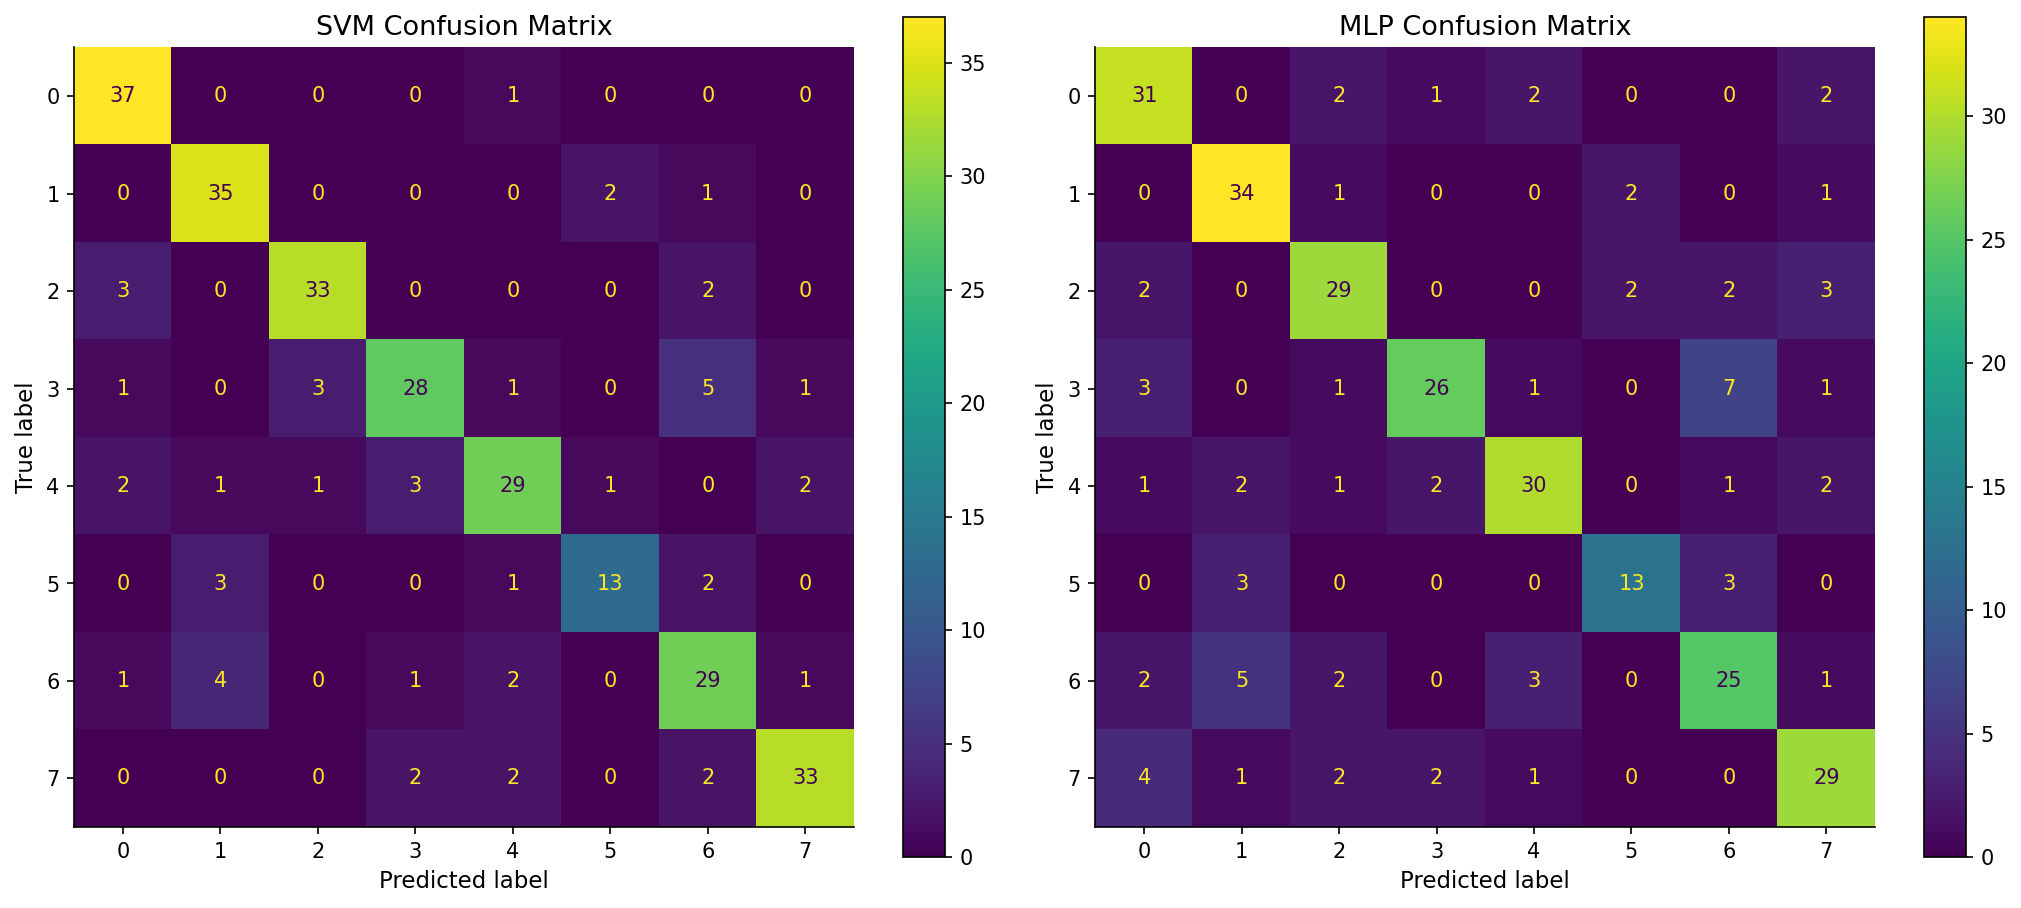

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=ax[0])
ax[0].set_title("SVM Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp, ax=ax[1])
ax[1].set_title("MLP Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("metadata.csv", index=False)
np.save("X.npy", X)
np.save("y.npy", y)